# გარემოს გამართვა


In [1]:
!pip install -q dagshub mlflow==2.22.0 pytorch_forecasting pytorch_lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from lightning.pytorch import Trainer

import mlflow

torch.manual_seed(42)
np.random.seed(42)

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
import dagshub
import mlflow

dagshub.init(
    repo_owner='aleko-mamukashvili',
    repo_name='Store-Sales-Forecasting',
    mlflow=True
)

mlflow.set_experiment("TFT_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=29107d1d-12b4-4db2-b592-efe4a91e052f&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=27fe9b4a5c1b3c303a7b98760ad233c3a961c26cd29e4730742ec4a5956b8b6d




Accessing as ndoda23

Initialized MLflow to track repo "aleko-mamukashvili/Store-Sales-Forecasting"

Repository aleko-mamukashvili/Store-Sales-Forecasting initialized!

<Experiment: artifact_location='mlflow-artifacts:/c2df16f2ba4242f4be0507f09ac28749', creation_time=1783854139379, experiment_id='7', last_update_time=1783854139379, lifecycle_stage='active', name='TFT_Training', tags={}>

In [4]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install -q kaggle
!kaggle datasets download -d aslanahmedov/walmart-sales-forecast
!unzip -o walmart-sales-forecast.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/aslanahmedov/walmart-sales-forecast
License(s): copyright-authors
100% 3.36M/3.36M [00:00<00:00, 257MB/s]

Archive:  walmart-sales-forecast.zip
  inflating: data/features.csv       
  inflating: data/stores.csv         
  inflating: data/test.csv           
  inflating: data/train.csv          


In [5]:
DATA_PATH = "data"

train_raw = pd.read_csv(f"{DATA_PATH}/train.csv")
features_raw = pd.read_csv(f"{DATA_PATH}/features.csv")
stores_raw = pd.read_csv(f"{DATA_PATH}/stores.csv")

df = train_raw.merge(features_raw, on=['Store', 'Date'], how='left', suffixes=('', '_feat'))
df = df.merge(stores_raw, on='Store', how='left')
if 'IsHoliday_feat' in df.columns:
    df = df.drop(columns=['IsHoliday_feat'])

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

print(df.shape)
df.head()

(421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


# EDA - Static/Known/Observed

## static candidates

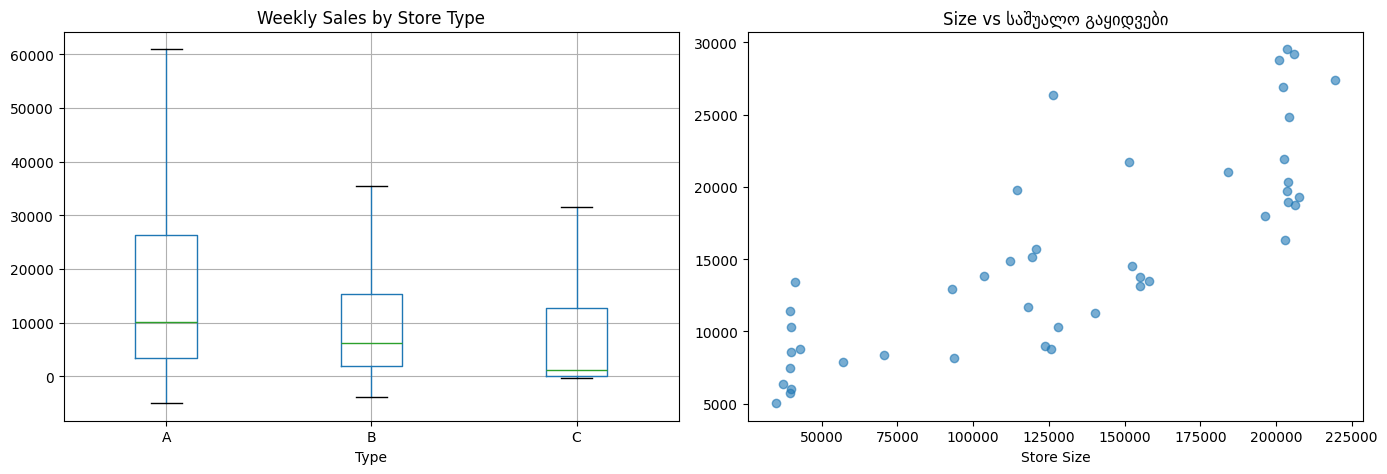

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.boxplot(column='Weekly_Sales', by='Type', ax=axes[0], showfliers=False)
axes[0].set_title('Weekly Sales by Store Type')
axes[1].scatter(stores_raw['Size'], stores_raw.merge(
    df.groupby('Store')['Weekly_Sales'].mean().reset_index(), on='Store')['Weekly_Sales'], alpha=0.6)
axes[1].set_xlabel('Store Size')
axes[1].set_title('Size vs საშუალო გაყიდვები')
plt.suptitle('')
plt.tight_layout()
plt.show()

## Known future Candidate

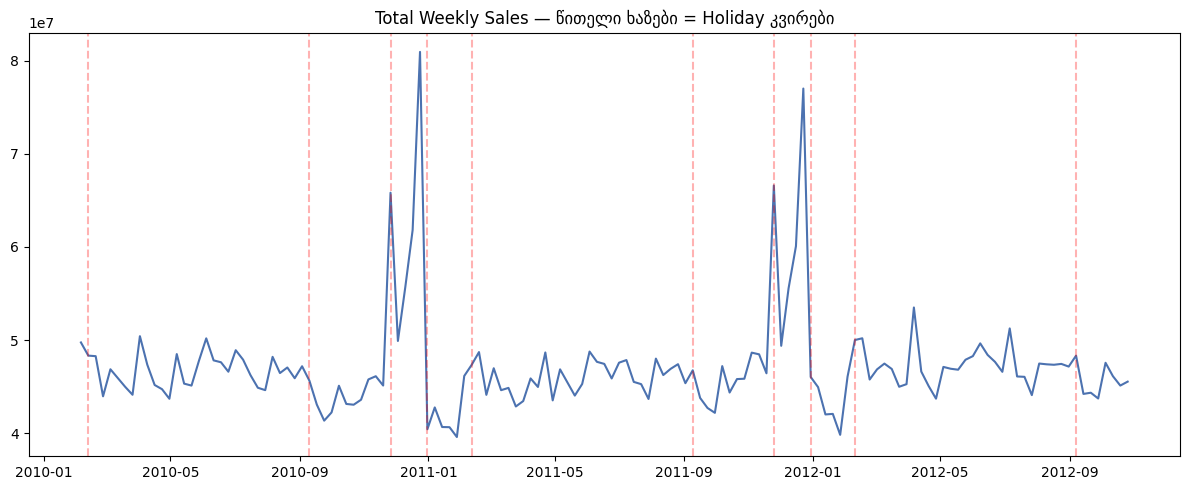

In [7]:
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()
holiday_dates = df[df['IsHoliday']]['Date'].unique()

fig, ax = plt.subplots()
ax.plot(weekly_total.index, weekly_total.values, color='#4C72B0')
for hd in holiday_dates:
    ax.axvline(hd, color='red', alpha=0.3, linestyle='--')
ax.set_title('Total Weekly Sales — წითელი ხაზები = Holiday კვირები')
plt.tight_layout()
plt.show()

## Observed/Unknown Candidates

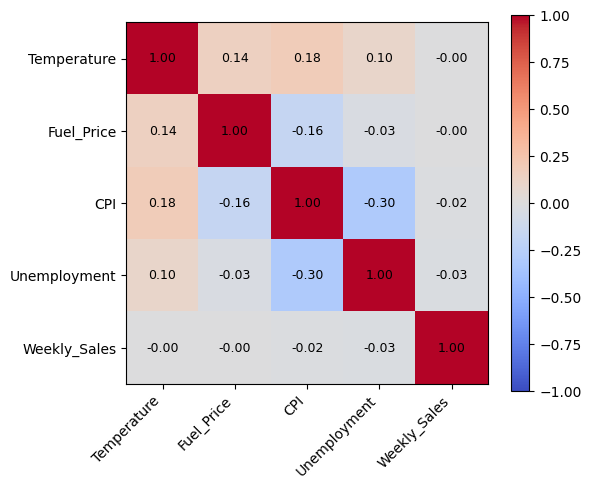

In [8]:
numeric_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Weekly_Sales']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols))); ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right'); ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im)
plt.tight_layout()
plt.show()

# Splitting


In [9]:
VAL_START = pd.Timestamp('2011-11-01')
VAL_END = pd.Timestamp('2012-02-15')

df_use = df[df['Date'] <= VAL_END].copy()

all_dates = sorted(df_use['Date'].unique())
date_to_idx = {d: i for i, d in enumerate(all_dates)}
idx_to_date = {i: d for d, i in date_to_idx.items()}
df_use['time_idx'] = df_use['Date'].map(date_to_idx)

training_cutoff = df_use[df_use['Date'] < VAL_START]['time_idx'].max()
print(f"Train: time_idx <= {training_cutoff}  ({df_use[df_use['time_idx'] <= training_cutoff]['Date'].max().date()})")
print(f"Val:   {VAL_START.date()} -> {VAL_END.date()}")

Train: time_idx <= 90  (2011-10-28)
Val:   2011-11-01 -> 2012-02-15


# Feature Engieering

## nan შევსება

In [10]:
df_use['group_id'] = df_use['Store'].astype(str) + '_' + df_use['Dept'].astype(str)
df_use['Store_str'] = df_use['Store'].astype(str)
df_use['Type'] = df_use['Type'].astype(str)
df_use['IsHoliday_str'] = df_use['IsHoliday'].astype(str)

train_mask = df_use['time_idx'] <= training_cutoff
for c in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']:
    train_mean = df_use.loc[train_mask, c].mean()  # fillna მხოლოდ train-საშუალოთი — leak-safe
    df_use[c] = df_use[c].fillna(train_mean)

print("NaN-ები დარჩენილია:", df_use[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].isna().sum().sum())

NaN-ები დარჩენილია: 0


## coverage შემოწმება

In [35]:
train_groups = set(df_use.loc[train_mask, 'group_id'].unique())
all_groups = df_use['group_id'].nunique()
df_f = df_use[df_use['group_id'].isin(train_groups)].copy()

print(f"Coverage: {len(train_groups)} / {all_groups} (Store, Dept) წყვილი გამოიყენება "
      f"({len(train_groups) / all_groups * 100:.1f}%)")

Coverage: 3254 / 3309 (Store, Dept) წყვილი გამოიყენება (98.3%)


## TimeSeriesDataSet ის აწყობა

In [12]:
MAX_ENCODER_LENGTH = 52
MAX_PREDICTION_LENGTH = 15  # ზუსტად ჩვენი holiday-aware validation window-ის სიგრძე

def build_datasets(static_categoricals, static_reals, known_categoricals, known_reals, unknown_reals):
    training_ds = TimeSeriesDataSet(
        df_f[df_f['time_idx'] <= training_cutoff],
        time_idx='time_idx', target='Weekly_Sales', group_ids=['group_id'],
        min_encoder_length=MAX_ENCODER_LENGTH, max_encoder_length=MAX_ENCODER_LENGTH,
        min_prediction_length=MAX_PREDICTION_LENGTH, max_prediction_length=MAX_PREDICTION_LENGTH,
        static_categoricals=static_categoricals, static_reals=static_reals,
        time_varying_known_categoricals=known_categoricals, time_varying_known_reals=known_reals,
        time_varying_unknown_reals=unknown_reals,
        target_normalizer=GroupNormalizer(groups=['group_id']),
        add_relative_time_idx=True, add_target_scales=True, allow_missing_timesteps=True,
    )
    validation_ds = TimeSeriesDataSet.from_dataset(training_ds, df_f, predict=True, stop_randomization=True)
    return training_ds, validation_ds

# მეტრიკები და MLflow Logging Helperebi

In [13]:
def wmae(y_true, y_pred, is_holiday):
    w = np.where(np.asarray(is_holiday).astype(bool), 5, 1)
    return np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w)


def evaluate_tft(model, validation_ds, batch_size=512):
    """
    row-level WMAE პირდაპირ, disaggregation-ის გარეშე (TFT-ის native multi-series unfold-ით).
    """
    val_loader = validation_ds.to_dataloader(train=False, batch_size=batch_size, num_workers=0)
    raw = model.predict(val_loader, mode="prediction", return_x=True)
    idx_df = validation_ds.x_to_index(raw.x)  # group_id + საწყისი time_idx თითო prediction-window-ზე
    preds = raw.output.numpy()  # shape: (n_series, MAX_PREDICTION_LENGTH)

    rows_true, rows_pred, rows_holiday = [], [], []
    val_lookup = df_f.set_index(['group_id', 'time_idx'])[['Weekly_Sales', 'IsHoliday']]

    for i, row in idx_df.iterrows():
        start_t = int(row['time_idx'])
        gid = row['group_id']
        for step in range(preds.shape[1]):
            t = start_t + step
            key = (gid, t)
            if key in val_lookup.index:
                actual_row = val_lookup.loc[key]
                rows_true.append(actual_row['Weekly_Sales'])
                rows_pred.append(max(preds[i, step], 0))
                rows_holiday.append(actual_row['IsHoliday'])

    return wmae(np.array(rows_true), np.array(rows_pred), np.array(rows_holiday)), len(rows_true)

# Experiment and MLflow logs

## baseline

In [14]:
def log_run(run_name, params, metrics, model=None, registered_name=None):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        if model is not None:
            mlflow.pytorch.log_model(model, "model", registered_model_name=registered_name)
        print(run_name, "->", metrics)

In [15]:
training_ds1, val_ds1 = build_datasets(
    static_categoricals=[], static_reals=[],
    known_categoricals=[], known_reals=['time_idx'],
    unknown_reals=['Weekly_Sales'],
)
train_loader1 = training_ds1.to_dataloader(train=True, batch_size=256, num_workers=0)

torch.manual_seed(42)
tft1 = TemporalFusionTransformer.from_dataset(
    training_ds1, hidden_size=8, attention_head_size=1, dropout=0.1,
    hidden_continuous_size=4, learning_rate=1e-3, lstm_layers=1,
)
trainer1 = Trainer(max_epochs=2, accelerator='cpu', enable_progress_bar=False, logger=False, enable_checkpointing=False)
trainer1.fit(tft1, train_dataloaders=train_loader1)

wmae_val1, n1 = evaluate_tft(tft1, val_ds1)
print(f"Run 1 — WMAE_val (row-level, n={n1}): {wmae_val1:.1f}")

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 241 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__group_id': '10_51'}, {'__group_id__group_id': '10_78'}, {'__group_id__group_id': '11_48'}, {'__group_id__group_id': '11_50'}, {'__group_id__group_id': '11_51'}, {'__group_id__group_id': '11_78'}, {'__group_id__group_id': '11_99'}, {'__group_id__group_id': '12_47'}, {'__group_id__group_id': '12_51'}, {'__group_id__group_id': '13_47'}]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 315 series/groups which therefore are not present i

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     40 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │    382 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │    618 │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │    398 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │    304 │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │    304 │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │    304 │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │    304 │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │    576 │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │    576 │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    144 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     16 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │    368 │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    280 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    160 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │    304 │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    160 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     63 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 5.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.2 K                                                                                                
Total estimated model params size (MB): 0.021                                                                      
Modules in train mode: 258                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/training_epoch_loop.py:500: ReduceLROnPlateau conditioned on metric val_loss which is not available but strict is set to `False`. Skipping learning rate update.
INFO: `Trainer.fit` stopped: `max_epochs=2` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and a

Run 1 — WMAE_val (row-level, n=43358): 5119.3


In [16]:
log_run(
    "TFT_Baseline",
    params={'features': 'target_only', 'hidden_size': 8, 'epochs': 2},
    metrics={'wmae_val': wmae_val1},
    model=tft1,
)

2026/07/12 11:14:08 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 11:14:25 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 11:14:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


TFT_Baseline -> {'wmae_val': np.float64(5119.3364288815865)}
🏃 View run TFT_Baseline at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7/runs/02cde6760fe9490a942ec420ad68feec
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7


## Run2 Static Features (Store Type,Size,Store ID)

In [17]:
training_ds2, val_ds2 = build_datasets(
    static_categoricals=['Store_str', 'Type'], static_reals=['Size'],
    known_categoricals=[], known_reals=['time_idx'],
    unknown_reals=['Weekly_Sales'],
)
train_loader2 = training_ds2.to_dataloader(train=True, batch_size=256, num_workers=0)

torch.manual_seed(42)
tft2 = TemporalFusionTransformer.from_dataset(
    training_ds2, hidden_size=8, attention_head_size=1, dropout=0.1,
    hidden_continuous_size=4, learning_rate=1e-3, lstm_layers=1,
)
trainer2 = Trainer(max_epochs=2, accelerator='cpu', enable_progress_bar=False, logger=False, enable_checkpointing=False)
trainer2.fit(tft2, train_dataloaders=train_loader2)

wmae_val2, n2 = evaluate_tft(tft2, val_ds2)
print(f"Run 2 — WMAE_val: {wmae_val2:.1f}")
print(f"(შედარებისთვის) Run 1: {wmae_val1:.1f}")

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 241 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__group_id': '10_51'}, {'__group_id__group_id': '10_78'}, {'__group_id__group_id': '11_48'}, {'__group_id__group_id': '11_50'}, {'__group_id__group_id': '11_51'}, {'__group_id__group_id': '11_78'}, {'__group_id__group_id': '11_99'}, {'__group_id__group_id': '12_47'}, {'__group_id__group_id': '12_51'}, {'__group_id__group_id': '13_47'}]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 315 series/groups which therefore are not present i

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    369 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     48 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │    787 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │    618 │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │    398 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │    304 │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │    304 │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │    304 │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │    304 │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │    576 │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │    576 │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    144 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     16 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │    368 │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    280 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    160 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │    304 │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    160 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     63 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 6.0 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.0 K                                                                                                
Total estimated model params size (MB): 0.024                                                                      
Modules in train mode: 282                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/training_epoch_loop.py:500: ReduceLROnPlateau conditioned on metric val_loss which is not available but strict is set to `False`. Skipping learning rate update.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Run 2 — WMAE_val: 4775.8
(შედარებისთვის) Run 1: 5119.3


In [18]:
log_run(
    "TFT_PlusStatic",
    params={'features': 'target+static(Store,Type,Size)', 'hidden_size': 8, 'epochs': 2},
    metrics={'wmae_val': wmae_val2},
    model=tft2,
)

2026/07/12 11:17:14 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 11:17:28 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 11:17:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


TFT_PlusStatic -> {'wmae_val': np.float64(4775.808968086772)}
🏃 View run TFT_PlusStatic at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7/runs/bd0e6bdfffc84cc58cfcfa5c8c49805d
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7


## Run3 Known-Future Feature(isHoliday)

In [19]:
training_ds3, val_ds3 = build_datasets(
    static_categoricals=['Store_str', 'Type'], static_reals=['Size'],
    known_categoricals=['IsHoliday_str'], known_reals=['time_idx'],
    unknown_reals=['Weekly_Sales'],
)
train_loader3 = training_ds3.to_dataloader(train=True, batch_size=256, num_workers=0)

torch.manual_seed(42)
tft3 = TemporalFusionTransformer.from_dataset(
    training_ds3, hidden_size=8, attention_head_size=1, dropout=0.1,
    hidden_continuous_size=4, learning_rate=1e-3, lstm_layers=1,
)
trainer3 = Trainer(max_epochs=2, accelerator='cpu', enable_progress_bar=False, logger=False, enable_checkpointing=False)
trainer3.fit(tft3, train_dataloaders=train_loader3)

wmae_val3, n3 = evaluate_tft(tft3, val_ds3)
print(f"Run 3 — WMAE_val: {wmae_val3:.1f}")
print(f"(შედარებისთვის) Run 2: {wmae_val2:.1f}")

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 241 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__group_id': '10_51'}, {'__group_id__group_id': '10_78'}, {'__group_id__group_id': '11_48'}, {'__group_id__group_id': '11_50'}, {'__group_id__group_id': '11_51'}, {'__group_id__group_id': '11_78'}, {'__group_id__group_id': '11_99'}, {'__group_id__group_id': '12_47'}, {'__group_id__group_id': '12_51'}, {'__group_id__group_id': '13_47'}]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 315 series/groups which therefore are not present i

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    371 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     48 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │    787 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │    696 │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │    465 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │    304 │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │    304 │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │    304 │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │    304 │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │    576 │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │    576 │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    144 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     16 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │    368 │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    280 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    160 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │    304 │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    160 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     63 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 6.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.2 K                                                                                                
Total estimated model params size (MB): 0.025                                                                      
Modules in train mode: 291                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/training_epoch_loop.py:500: ReduceLROnPlateau conditioned on metric val_loss which is not available but strict is set to `False`. Skipping learning rate update.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Run 3 — WMAE_val: 4912.4
(შედარებისთვის) Run 2: 4775.8


In [20]:
log_run(
    "TFT_PlusKnownHoliday",
    params={'features': 'target+static+known(IsHoliday)', 'hidden_size': 8, 'epochs': 2},
    metrics={'wmae_val': wmae_val3},
    model=tft3,
)

2026/07/12 11:20:23 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 11:20:36 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 11:20:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


TFT_PlusKnownHoliday -> {'wmae_val': np.float64(4912.410459907281)}
🏃 View run TFT_PlusKnownHoliday at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7/runs/a70fcaca76f44306a134c76f0d99fef1
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7



## Run4 Observed Covaraites(Temp,FuelPr,CPI,Unemployment)

In [21]:
training_ds4, val_ds4 = build_datasets(
    static_categoricals=['Store_str', 'Type'], static_reals=['Size'],
    known_categoricals=['IsHoliday_str'], known_reals=['time_idx'],
    unknown_reals=['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment'],
)
train_loader4 = training_ds4.to_dataloader(train=True, batch_size=256, num_workers=0)

torch.manual_seed(42)
tft4 = TemporalFusionTransformer.from_dataset(
    training_ds4, hidden_size=8, attention_head_size=1, dropout=0.1,
    hidden_continuous_size=4, learning_rate=1e-3, lstm_layers=1,
)
trainer4 = Trainer(max_epochs=2, accelerator='cpu', enable_progress_bar=False, logger=False, enable_checkpointing=False)
trainer4.fit(tft4, train_dataloaders=train_loader4)

wmae_val4, n4 = evaluate_tft(tft4, val_ds4)
print(f"Run 4 — WMAE_val (სრული feature-set): {wmae_val4:.1f}")
print(f"(შედარებისთვის) Run 3: {wmae_val3:.1f}")

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 241 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__group_id': '10_51'}, {'__group_id__group_id': '10_78'}, {'__group_id__group_id': '11_48'}, {'__group_id__group_id': '11_50'}, {'__group_id__group_id': '11_51'}, {'__group_id__group_id': '11_78'}, {'__group_id__group_id': '11_99'}, {'__group_id__group_id': '12_47'}, {'__group_id__group_id': '12_51'}, {'__group_id__group_id': '13_47'}]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 315 series/groups which therefore are not present i

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    371 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     80 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │    787 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │    465 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │    304 │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │    304 │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │    304 │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │    304 │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │    576 │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │    576 │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    144 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     16 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │    368 │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    280 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    160 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │    304 │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    160 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     63 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 7.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.2 K                                                                                                
Total estimated model params size (MB): 0.029                                                                      
Modules in train mode: 351                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/training_epoch_loop.py:500: ReduceLROnPlateau conditioned on metric val_loss which is not available but strict is set to `False`. Skipping learning rate update.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Run 4 — WMAE_val (სრული feature-set): 4520.4
(შედარებისთვის) Run 3: 4912.4


In [22]:
log_run(
    "TFT_PlusObservedCovariates",
    params={'features': 'full', 'hidden_size': 8, 'epochs': 2},
    metrics={'wmae_val': wmae_val4},
    model=tft4,
)

2026/07/12 11:24:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 11:24:16 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 11:24:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


TFT_PlusObservedCovariates -> {'wmae_val': np.float64(4520.425997370383)}
🏃 View run TFT_PlusObservedCovariates at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7/runs/2363564aee51439997fe754e0c4b2eb4
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7


## Run5 hidden_size=16 უფრო ფართო ქსელი

In [23]:
training_ds5, val_ds5 = build_datasets(
    static_categoricals=['Store_str', 'Type'], static_reals=['Size'],
    known_categoricals=['IsHoliday_str'], known_reals=['time_idx'],
    unknown_reals=['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment'],
)
train_loader5 = training_ds5.to_dataloader(train=True, batch_size=256, num_workers=0)

torch.manual_seed(42)
tft5 = TemporalFusionTransformer.from_dataset(
    training_ds5, hidden_size=16, attention_head_size=2, dropout=0.1,
    hidden_continuous_size=8, learning_rate=1e-3, lstm_layers=1,
)
trainer5 = Trainer(max_epochs=2, accelerator='cpu', enable_progress_bar=False, logger=False, enable_checkpointing=False)
trainer5.fit(tft5, train_dataloaders=train_loader5)

wmae_val5, n5 = evaluate_tft(tft5, val_ds5)
print(f"Run 5 (hidden=16, heads=2) — WMAE_val: {wmae_val5:.1f}")
print(f"(შედარებისთვის) Run 4 (hidden=8, heads=1): {wmae_val4:.1f}")

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 241 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__group_id': '10_51'}, {'__group_id__group_id': '10_78'}, {'__group_id__group_id': '11_48'}, {'__group_id__group_id': '11_50'}, {'__group_id__group_id': '11_51'}, {'__group_id__group_id': '11_78'}, {'__group_id__group_id': '11_99'}, {'__group_id__group_id': '12_47'}, {'__group_id__group_id': '12_51'}, {'__group_id__group_id': '13_47'}]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 315 series/groups which therefore are not present i

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    596 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    160 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  4.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 22.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 22.4 K                                                                                               
Total estimated model params size (MB): 0.090                                                                      
Modules in train mode: 354                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/training_epoch_loop.py:500: ReduceLROnPlateau conditioned on metric val_loss which is not available but strict is set to `False`. Skipping learning rate update.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Run 5 (hidden=16, heads=2) — WMAE_val: 4969.2
(შედარებისთვის) Run 4 (hidden=8, heads=1): 4520.4


In [24]:
log_run(
    "TFT_WiderNetwork",
    params={'hidden_size': 16, 'attention_head_size': 2, 'epochs': 2},
    metrics={'wmae_val': wmae_val5},
    model=tft5,
)

2026/07/12 11:28:36 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 11:28:50 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 11:28:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


TFT_WiderNetwork -> {'wmae_val': np.float64(4969.233559789344)}
🏃 View run TFT_WiderNetwork at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7/runs/c918e7062feb447caf8253da9c519a1a
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7


## Run6 Learning Rate შემცირება+ მეტი epoch

In [25]:
torch.manual_seed(42)
tft6 = TemporalFusionTransformer.from_dataset(
    training_ds4, hidden_size=8, attention_head_size=1, dropout=0.1,
    hidden_continuous_size=4, learning_rate=5e-4, lstm_layers=1,
)
trainer6 = Trainer(max_epochs=3, accelerator='cpu', enable_progress_bar=False, logger=False, enable_checkpointing=False)
trainer6.fit(tft6, train_dataloaders=train_loader4)

wmae_val6, n6 = evaluate_tft(tft6, val_ds4)
print(f"Run 6 (lr=5e-4, 3 epochs) — WMAE_val: {wmae_val6:.1f}")

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](ht

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    371 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     80 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │    787 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │    465 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │    304 │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │    304 │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │    304 │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │    304 │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │    576 │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │    576 │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    144 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     16 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │    368 │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    280 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    160 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │    304 │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    160 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     63 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 7.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.2 K                                                                                                
Total estimated model params size (MB): 0.029                                                                      
Modules in train mode: 351                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/training_epoch_loop.py:500: ReduceLROnPlateau conditioned on metric val_loss which is not available but strict is set to `False`. Skipping learning rate update.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Run 6 (lr=5e-4, 3 epochs) — WMAE_val: 4770.3


In [26]:
log_run(
    "TFT_LowerLR_MoreEpochs",
    params={'learning_rate': 5e-4, 'epochs': 3, 'hidden_size': 8},
    metrics={'wmae_val': wmae_val6},
    model=tft6,
)

2026/07/12 11:33:48 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 11:34:02 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 11:34:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


TFT_LowerLR_MoreEpochs -> {'wmae_val': np.float64(4770.323547308347)}
🏃 View run TFT_LowerLR_MoreEpochs at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7/runs/97ec861a15c845f6a15de11db0ff8e17
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7


## Run7 Hyperparameter Search + ღრმა ტრენინგნი

In [27]:
INTERNAL_VAL_WEEKS = 15
internal_cutoff = training_cutoff - INTERNAL_VAL_WEEKS

def build_datasets_cutoff(cutoff, static_categoricals, static_reals, known_categoricals,
                           known_reals, unknown_reals, full_df=df_f):
    groups_seen = set(full_df[full_df['time_idx'] <= cutoff]['group_id'].unique())
    sub_df = full_df[full_df['group_id'].isin(groups_seen)].copy()
    train_part = sub_df[sub_df['time_idx'] <= cutoff]
    training_ds = TimeSeriesDataSet(
        train_part,
        time_idx='time_idx', target='Weekly_Sales', group_ids=['group_id'],
        min_encoder_length=MAX_ENCODER_LENGTH, max_encoder_length=MAX_ENCODER_LENGTH,
        min_prediction_length=MAX_PREDICTION_LENGTH, max_prediction_length=MAX_PREDICTION_LENGTH,
        static_categoricals=static_categoricals, static_reals=static_reals,
        time_varying_known_categoricals=known_categoricals, time_varying_known_reals=known_reals,
        time_varying_unknown_reals=unknown_reals,
        target_normalizer=GroupNormalizer(groups=['group_id']),
        add_relative_time_idx=True, add_target_scales=True, allow_missing_timesteps=True,
    )
    eval_part = sub_df[sub_df['time_idx'] <= cutoff + MAX_PREDICTION_LENGTH]
    validation_ds = TimeSeriesDataSet.from_dataset(training_ds, eval_part, predict=True, stop_randomization=True)
    return training_ds, validation_ds, sub_df


internal_training_ds, internal_val_ds, internal_lookup_df = build_datasets_cutoff(
    internal_cutoff,
    static_categoricals=['Store_str', 'Type'], static_reals=['Size'],
    known_categoricals=['IsHoliday_str'], known_reals=['time_idx'],
    unknown_reals=['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment'],
)
internal_train_loader = internal_training_ds.to_dataloader(train=True, batch_size=256, num_workers=0)
print('Internal train cutoff:', internal_cutoff, '| Internal val:', internal_cutoff + 1, '->', internal_cutoff + MAX_PREDICTION_LENGTH)

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 284 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__group_id': '10_51'}, {'__group_id__group_id': '10_78'}, {'__group_id__group_id': '11_47'}, {'__group_id__group_id': '11_48'}, {'__group_id__group_id': '11_50'}, {'__group_id__group_id': '11_51'}, {'__group_id__group_id': '11_78'}, {'__group_id__group_id': '11_99'}, {'__group_id__group_id': '12_47'}, {'__group_id__group_id': '12_51'}]
  warnings.warn(


Internal train cutoff: 75 | Internal val: 76 -> 90


/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 339 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__group_id': '10_18'}, {'__group_id__group_id': '10_47'}, {'__group_id__group_id': '10_51'}, {'__group_id__group_id': '10_78'}, {'__group_id__group_id': '11_19'}, {'__group_id__group_id': '11_47'}, {'__group_id__group_id': '11_48'}, {'__group_id__group_id': '11_50'}, {'__group_id__group_id': '11_51'}, {'__group_id__group_id': '11_60'}]
  warnings.warn(


In [28]:
def evaluate_tft_generic(model, validation_ds, lookup_df, batch_size=512):
    val_loader = validation_ds.to_dataloader(train=False, batch_size=batch_size, num_workers=0)
    raw = model.predict(val_loader, mode='prediction', return_x=True)
    idx_df = validation_ds.x_to_index(raw.x)
    preds = raw.output.numpy()

    rows_true, rows_pred, rows_holiday = [], [], []
    lookup = lookup_df.set_index(['group_id', 'time_idx'])[['Weekly_Sales', 'IsHoliday']]

    for i, row in idx_df.iterrows():
        start_t = int(row['time_idx']); gid = row['group_id']
        for step in range(preds.shape[1]):
            key = (gid, start_t + step)
            if key in lookup.index:
                actual_row = lookup.loc[key]
                rows_true.append(actual_row['Weekly_Sales'])
                rows_pred.append(max(preds[i, step], 0))
                rows_holiday.append(actual_row['IsHoliday'])

    return wmae(np.array(rows_true), np.array(rows_pred), np.array(rows_holiday)), len(rows_true)

In [29]:
random_search_space = {
    'hidden_size': [8, 16],
    'attention_head_size': [1, 2],
    'hidden_continuous_size': [4, 8],
    'dropout': [0.1, 0.15, 0.2],
    'learning_rate': [1e-3, 5e-4],
}

N_SEARCH_TRIALS = 5
SEARCH_EPOCHS = 3
search_results = []

for trial in range(N_SEARCH_TRIALS):
    rng = np.random.RandomState(300 + trial)
    params = {k: v[rng.randint(len(v))] for k, v in random_search_space.items()}

    torch.manual_seed(300 + trial)
    trial_model = TemporalFusionTransformer.from_dataset(
        internal_training_ds, hidden_size=params['hidden_size'],
        attention_head_size=params['attention_head_size'], dropout=params['dropout'],
        hidden_continuous_size=params['hidden_continuous_size'],
        learning_rate=params['learning_rate'], lstm_layers=1,
    )
    trial_trainer = Trainer(max_epochs=SEARCH_EPOCHS, accelerator='cpu', enable_progress_bar=False,
                             logger=False, enable_checkpointing=False)
    trial_trainer.fit(trial_model, train_dataloaders=internal_train_loader)

    trial_wmae, trial_n = evaluate_tft_generic(trial_model, internal_val_ds, internal_lookup_df)
    search_results.append((params, trial_wmae))
    print(f'Trial {trial+1}/{N_SEARCH_TRIALS}: internal_wmae={trial_wmae:.1f} (n={trial_n})  params={params}')

best_params, best_internal_wmae = min(search_results, key=lambda r: r[1])
print()
print('საუკეთესო კონფიგურაცია random search-იდან:', best_params, '| internal_wmae =', best_internal_wmae)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](ht

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    596 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    160 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  4.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 22.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 22.4 K                                                                                               
Total estimated model params size (MB): 0.090                                                                      
Modules in train mode: 354                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/training_epoch_loop.py:500: ReduceLROnPlateau conditioned on metric val_loss which is not available but strict is set to `False`. Skipping learning rate update.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Trial 1/5: internal_wmae=2566.9 (n=42735)  params={'hidden_size': 16, 'attention_head_size': 2, 'hidden_continuous_size': 8, 'dropout': 0.2, 'learning_rate': 0.001}


...

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](ht

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    596 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    160 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  4.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 22.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 22.7 K                                                                                               
Total estimated model params size (MB): 0.091                                                                      
Modules in train mode: 352                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/training_epoch_loop.py:500: ReduceLROnPlateau conditioned on metric val_loss which is not available but strict is set to `False`. Skipping learning rate update.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Trial 5/5: internal_wmae=2268.7 (n=42735)  params={'hidden_size': 16, 'attention_head_size': 1, 'hidden_continuous_size': 8, 'dropout': 0.2, 'learning_rate': 0.0005}

საუკეთესო კონფიგურაცია random search-იდან: {'hidden_size': 16, 'attention_head_size': 1, 'hidden_continuous_size': 8, 'dropout': 0.2, 'learning_rate': 0.0005} | internal_wmae = 2268.6741201805057


In [30]:
FINAL_EPOCHS = 10

torch.manual_seed(999)
tft_deep = TemporalFusionTransformer.from_dataset(
    training_ds4, hidden_size=best_params['hidden_size'],
    attention_head_size=best_params['attention_head_size'], dropout=best_params['dropout'],
    hidden_continuous_size=best_params['hidden_continuous_size'],
    learning_rate=best_params['learning_rate'], lstm_layers=1,
)
trainer_deep = Trainer(max_epochs=FINAL_EPOCHS, accelerator='cpu', enable_progress_bar=False,
                        logger=False, enable_checkpointing=False)
trainer_deep.fit(tft_deep, train_dataloaders=train_loader4)

wmae_val_deep, n_deep = evaluate_tft(tft_deep, val_ds4)
print(f'Deep TFT (search + {FINAL_EPOCHS} epochs) - WMAE_val (n={n_deep}): {wmae_val_deep:.1f}')
print('(shedarebistvis) Run 1-6 saukeTeso: ' + format(min(wmae_val1, wmae_val2, wmae_val3, wmae_val4, wmae_val5, wmae_val6), '.1f'))

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](ht

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    596 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    160 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  4.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 22.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 22.7 K                                                                                               
Total estimated model params size (MB): 0.091                                                                      
Modules in train mode: 352                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/training_epoch_loop.py:500: ReduceLROnPlateau conditioned on metric val_loss which is not available but strict is set to `False`. Skipping learning rate update.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Deep TFT (search + 10 epochs) - WMAE_val (n=43358): 4439.6
(shedarebistvis) Run 1-6 saukeTeso: 4520.4


In [31]:
log_run(
    'TFT_DeepSearch',
    params={**best_params, 'epochs': FINAL_EPOCHS, 'search_trials': N_SEARCH_TRIALS,
            'search_epochs': SEARCH_EPOCHS},
    metrics={'wmae_val': wmae_val_deep, 'internal_search_wmae': best_internal_wmae},
    model=tft_deep,
)

2026/07/12 12:06:53 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 12:07:06 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 12:07:06 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


TFT_DeepSearch -> {'wmae_val': np.float64(4439.605311099393), 'internal_search_wmae': np.float64(2268.6741201805057)}
🏃 View run TFT_DeepSearch at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7/runs/bebee638606b418294942676fb7a320c
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7


In [32]:
all_runs = {
    'Baseline': wmae_val1,
    'PlusStatic': wmae_val2,
    'PlusKnownHoliday': wmae_val3,
    'PlusObservedCovariates': wmae_val4,
    'WiderNetwork': wmae_val5,
    'LowerLR_MoreEpochs': wmae_val6,
    'DeepSearch': wmae_val_deep,
}
for name, v in sorted(all_runs.items(), key=lambda x: x[1]):
    print(f"{name}: {v:.1f}")

best_name = min(all_runs, key=all_runs.get)
print("\nსაუკეთესო კონფიგურაცია:", best_name, "WMAE_val =", all_runs[best_name])

DeepSearch: 4439.6
PlusObservedCovariates: 4520.4
LowerLR_MoreEpochs: 4770.3
PlusStatic: 4775.8
PlusKnownHoliday: 4912.4
WiderNetwork: 4969.2
Baseline: 5119.3

საუკეთესო კონფიგურაცია: DeepSearch WMAE_val = 4439.605311099393


## საბოლოო მოდელის შერჩევა და რეგისტრაცია

In [33]:
model_map = {
    'Baseline': tft1, 'PlusStatic': tft2, 'PlusKnownHoliday': tft3,
    'PlusObservedCovariates': tft4, 'WiderNetwork': tft5, 'LowerLR_MoreEpochs': tft6, 'DeepSearch': tft_deep,
}
final_model = model_map[best_name]

log_run(
    "TFT_Final",
    params={'selected_config': best_name, 'max_encoder_length': MAX_ENCODER_LENGTH,
            'max_prediction_length': MAX_PREDICTION_LENGTH},
    metrics={'wmae_val_row_level': all_runs[best_name]},
    model=final_model,
    registered_name="TFT_WalmartSales",
)

2026/07/12 12:07:08 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 12:07:22 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/12 12:07:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'TFT_W

TFT_Final -> {'wmae_val_row_level': np.float64(4439.605311099393)}
🏃 View run TFT_Final at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7/runs/a7c7d207612d447e993930d595a371f8
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/Store-Sales-Forecasting.mlflow/#/experiments/7


In [34]:
print("TFT (საუკეთესო):", all_runs[best_name])
print("N-BEATS (Global Multi-Series + Ensemble): 3727.7")
print("Prophet (disaggregated): 4872.0")
print("LightGBM (საუკეთესო): 2746.5")

TFT (საუკეთესო): 4439.605311099393
N-BEATS (Global Multi-Series + Ensemble): 3727.7
Prophet (disaggregated): 4872.0
LightGBM (საუკეთესო): 2746.5
